<a href="https://colab.research.google.com/github/ps-research/COMET/blob/main/QCE_COMET_Part_1_%5BSimulators_and_Benchmarking%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMET: Combinatorial Optimization for Multiplex Editing Therapies
## QUBO + QAOA for Multiplex CRISPR Guide RNA Selection
### IEEE QCE 2026 — Proof of Concept Implementation

**Pipeline:** Synthetic gRNA Data → QUBO → Classical Baselines → QAOA (Simulator) → QAOA (Hardware)

**Key experiments:**
- Option A: Standard QAOA with penalty sweep (P = 2, 3, 5, auto)
- Option B: XY-mixer QAOA (constraint-preserving, no penalty needed)

## Cell 1: Imports & Setup

In [ ]:
# COMET - Colab Setup
!pip install qiskit qiskit-aer qiskit-ibm-runtime qiskit-algorithms qiskit-optimization -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.4/647.4 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.7/378.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.2 MB/s eta 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

# Qiskit Core
from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit import QuantumCircuit

# Qiskit Optimization
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

print("All imports successful!")
print(f"NumPy version: {np.__version__}")

All imports successful!
NumPy version: 2.0.2


---
## PHASE 1: Problem Setup & QUBO Construction
---

### Cell 2: Synthetic gRNA Data Generation

**3 genes × 4 candidates = 12 binary variables**

Data is synthetic but designed to be biologically plausible:
- On-target scores: 0.5–0.95 range (typical for real gRNAs)
- Off-target scores: 0.02–0.45 range (typical risk levels)
- Pairwise interactions: sparse, mostly near-zero, with a few significant pairs

**Key design choice:** gRNA_0 (Gene A) and gRNA_4 (Gene B) are individually
the best candidates for their genes, BUT have a strong negative interaction.
This creates the "best team ≠ best individuals" scenario that motivates QUBO.

In [ ]:
# ============================================================
# SYNTHETIC gRNA DATA
# ============================================================

# Problem dimensions
M = 3   # number of genes
N = 4   # candidates per gene
n = M * N  # total binary variables = 12

# Gene labels for readability
GENE_NAMES = ["Gene_A (PDCD1)", "Gene_B (LAG3)", "Gene_C (HAVCR2)"]
gene_assignment = {i: GENE_NAMES[i // N] for i in range(n)}

# --- On-target efficacy scores (higher = better) ---
on_target = np.array([
    # Gene A (PDCD1) candidates
    0.92,  # x0: excellent efficacy
    0.78,  # x1: good efficacy
    0.85,  # x2: very good efficacy
    0.71,  # x3: moderate efficacy
    # Gene B (LAG3) candidates
    0.88,  # x4: very good efficacy
    0.76,  # x5: good efficacy
    0.82,  # x6: good efficacy
    0.69,  # x7: moderate efficacy
    # Gene C (HAVCR2) candidates
    0.90,  # x8: excellent efficacy
    0.84,  # x9: very good efficacy
    0.73,  # x10: moderate efficacy
    0.80,  # x11: good efficacy
])

# --- Off-target risk scores (lower = safer) ---
off_target = np.array([
    # Gene A (PDCD1) candidates
    0.15,  # x0: moderate risk
    0.05,  # x1: very safe
    0.30,  # x2: risky
    0.08,  # x3: safe
    # Gene B (LAG3) candidates
    0.20,  # x4: moderate risk
    0.07,  # x5: safe
    0.12,  # x6: moderate risk
    0.35,  # x7: risky
    # Gene C (HAVCR2) candidates
    0.25,  # x8: moderate-high risk
    0.10,  # x9: safe-moderate
    0.04,  # x10: very safe
    0.18,  # x11: moderate risk
])

# --- Weights for linear cost ---
w_on = 1.0    # weight for on-target (reward)
w_off = 1.0   # weight for off-target (penalty)

# --- Compute linear costs L_i ---
# L_i = w_off * OffTarget(i) - w_on * OnTarget(i)
# More negative = better candidate
L = w_off * off_target - w_on * on_target

print("=" * 60)
print("LINEAR COSTS (L_i): Individual gRNA Quality")
print("=" * 60)
print(f"{'Var':<5} {'Gene':<22} {'OnTarget':<10} {'OffTarget':<10} {'L_i':<10} {'Quality'}")
print("-" * 75)
for i in range(n):
    quality = "★★★" if L[i] < -0.7 else ("★★" if L[i] < -0.5 else "★")
    print(f"x{i:<4} {gene_assignment[i]:<22} {on_target[i]:<10.2f} {off_target[i]:<10.2f} {L[i]:<10.3f} {quality}")

LINEAR COSTS (L_i): Individual gRNA Quality
Var   Gene                   OnTarget   OffTarget  L_i        Quality
---------------------------------------------------------------------------
x0    Gene_A (PDCD1)         0.92       0.15       -0.770     ★★★
x1    Gene_A (PDCD1)         0.78       0.05       -0.730     ★★★
x2    Gene_A (PDCD1)         0.85       0.30       -0.550     ★★
x3    Gene_A (PDCD1)         0.71       0.08       -0.630     ★★
x4    Gene_B (LAG3)          0.88       0.20       -0.680     ★★
x5    Gene_B (LAG3)          0.76       0.07       -0.690     ★★
x6    Gene_B (LAG3)          0.82       0.12       -0.700     ★★
x7    Gene_B (LAG3)          0.69       0.35       -0.340     ★
x8    Gene_C (HAVCR2)        0.90       0.25       -0.650     ★★
x9    Gene_C (HAVCR2)        0.84       0.10       -0.740     ★★★
x10   Gene_C (HAVCR2)        0.73       0.04       -0.690     ★★
x11   Gene_C (HAVCR2)        0.80       0.18       -0.620     ★★


### Cell 3: Pairwise Interaction Matrix (Q_ij)

Interactions exist only between candidates of **different genes**.
Same-gene pairs have Q_ij = 0 (constraints handle those).

**The trap:** x0 (best for Gene A) and x4 (best for Gene B) have
a strong synergistic toxicity interaction (Q = +0.80). Their off-target
sites hit the same pathway. The optimizer must find a team that avoids this.


In [ ]:
# ============================================================
# PAIRWISE INTERACTION MATRIX Q_ij
# ============================================================

# Initialize all interactions to zero
Q_interaction = np.zeros((n, n))

# --- Cross-gene interactions ---
# Format: Q_interaction[i][j] = interaction cost
# Positive = bad pair (synergistic toxicity, resource competition)
# Negative = good pair (beneficial synergy)
# Zero = no significant interaction

# Gene A <-> Gene B interactions
Q_interaction[0][4] = +0.80   # x0-x4: STRONG synergistic toxicity (THE TRAP)
Q_interaction[0][5] = +0.05   # x0-x5: negligible
Q_interaction[0][6] = -0.10   # x0-x6: slight beneficial synergy
Q_interaction[0][7] = +0.15   # x0-x7: mild competition
Q_interaction[1][4] = +0.10   # x1-x4: mild interaction
Q_interaction[1][5] = -0.15   # x1-x5: beneficial synergy
Q_interaction[1][6] = +0.05   # x1-x6: negligible
Q_interaction[1][7] = +0.03   # x1-x7: negligible
Q_interaction[2][4] = +0.20   # x2-x4: moderate competition
Q_interaction[2][5] = +0.08   # x2-x5: mild
Q_interaction[2][6] = +0.12   # x2-x6: mild competition
Q_interaction[2][7] = -0.05   # x2-x7: slight synergy
Q_interaction[3][4] = +0.06   # x3-x4: negligible
Q_interaction[3][5] = -0.08   # x3-x5: slight synergy
Q_interaction[3][6] = +0.04   # x3-x6: negligible
Q_interaction[3][7] = +0.02   # x3-x7: negligible

# Gene A <-> Gene C interactions
Q_interaction[0][8]  = +0.25  # x0-x8: moderate toxicity
Q_interaction[0][9]  = -0.05  # x0-x9: slight synergy
Q_interaction[0][10] = +0.03  # x0-x10: negligible
Q_interaction[0][11] = +0.10  # x0-x11: mild
Q_interaction[1][8]  = +0.08  # x1-x8: mild
Q_interaction[1][9]  = +0.04  # x1-x9: negligible
Q_interaction[1][10] = -0.12  # x1-x10: beneficial synergy
Q_interaction[1][11] = +0.06  # x1-x11: negligible
Q_interaction[2][8]  = +0.15  # x2-x8: mild-moderate
Q_interaction[2][9]  = +0.07  # x2-x9: mild
Q_interaction[2][10] = +0.09  # x2-x10: mild
Q_interaction[2][11] = -0.08  # x2-x11: slight synergy
Q_interaction[3][8]  = +0.05  # x3-x8: negligible
Q_interaction[3][9]  = -0.10  # x3-x9: beneficial synergy
Q_interaction[3][10] = +0.02  # x3-x10: negligible
Q_interaction[3][11] = +0.04  # x3-x11: negligible

# Gene B <-> Gene C interactions
Q_interaction[4][8]  = +0.30  # x4-x8: moderate-strong toxicity
Q_interaction[4][9]  = +0.12  # x4-x9: mild competition
Q_interaction[4][10] = +0.06  # x4-x10: negligible
Q_interaction[4][11] = -0.10  # x4-x11: slight synergy
Q_interaction[5][8]  = +0.07  # x5-x8: mild
Q_interaction[5][9]  = -0.08  # x5-x9: slight synergy
Q_interaction[5][10] = +0.03  # x5-x10: negligible
Q_interaction[5][11] = +0.05  # x5-x11: negligible
Q_interaction[6][8]  = +0.10  # x6-x8: mild
Q_interaction[6][9]  = +0.06  # x6-x9: negligible
Q_interaction[6][10] = -0.07  # x6-x10: slight synergy
Q_interaction[6][11] = +0.08  # x6-x11: mild
Q_interaction[7][8]  = +0.18  # x7-x8: moderate
Q_interaction[7][9]  = +0.04  # x7-x9: negligible
Q_interaction[7][10] = +0.02  # x7-x10: negligible
Q_interaction[7][11] = +0.09  # x7-x11: mild

print("=" * 60)
print("NOTABLE PAIRWISE INTERACTIONS")
print("=" * 60)
print(f"{'Pair':<12} {'Q_ij':<8} {'Type'}")
print("-" * 40)
for i in range(n):
    for j in range(i+1, n):
        if abs(Q_interaction[i][j]) >= 0.10:
            itype = "⚠️ TOXICITY" if Q_interaction[i][j] > 0 else "✅ SYNERGY"
            print(f"x{i}-x{j}      {Q_interaction[i][j]:>+.2f}    {itype}")

print(f"\n🚨 KEY TRAP: x0 (best Gene A) + x4 (best Gene B) = Q={Q_interaction[0][4]:+.2f}")
print("   Individually optimal picks have the WORST pairwise interaction!")

NOTABLE PAIRWISE INTERACTIONS
Pair         Q_ij     Type
----------------------------------------
x0-x4      +0.80    ⚠️ TOXICITY
x0-x6      -0.10    ✅ SYNERGY
x0-x7      +0.15    ⚠️ TOXICITY
x0-x8      +0.25    ⚠️ TOXICITY
x0-x11      +0.10    ⚠️ TOXICITY
x1-x4      +0.10    ⚠️ TOXICITY
x1-x5      -0.15    ✅ SYNERGY
x1-x10      -0.12    ✅ SYNERGY
x2-x4      +0.20    ⚠️ TOXICITY
x2-x6      +0.12    ⚠️ TOXICITY
x2-x8      +0.15    ⚠️ TOXICITY
x3-x9      -0.10    ✅ SYNERGY
x4-x8      +0.30    ⚠️ TOXICITY
x4-x9      +0.12    ⚠️ TOXICITY
x4-x11      -0.10    ✅ SYNERGY
x6-x8      +0.10    ⚠️ TOXICITY
x7-x8      +0.18    ⚠️ TOXICITY

🚨 KEY TRAP: x0 (best Gene A) + x4 (best Gene B) = Q=+0.80
   Individually optimal picks have the WORST pairwise interaction!


### Cell 4: Build QuadraticProgram (Constrained)

 This is the base constrained problem. Cell 5 will create multiple QUBO variants from it.

In [ ]:
# ============================================================
# BUILD QUADRATIC PROGRAM
# ============================================================

qp = QuadraticProgram("COMET_gRNA_Selection")

# --- Step 1: Declare 12 binary variables ---
var_names = [f"x{i}" for i in range(n)]
for name in var_names:
    qp.binary_var(name=name)

# --- Step 2: Set objective (minimize) ---
# Linear terms: L_i for each variable
linear_dict = {f"x{i}": float(L[i]) for i in range(n)}

# Quadratic terms: Q_ij for cross-gene pairs
quadratic_dict = {}
for i in range(n):
    for j in range(i+1, n):
        if abs(Q_interaction[i][j]) > 1e-10:  # skip exact zeros
            quadratic_dict[(f"x{i}", f"x{j}")] = float(Q_interaction[i][j])

qp.minimize(linear=linear_dict, quadratic=quadratic_dict)

# --- Step 3: Add constraints (one gRNA per gene) ---
for k in range(M):
    start = k * N
    constraint_vars = {f"x{i}": 1 for i in range(start, start + N)}
    qp.linear_constraint(
        linear=constraint_vars,
        sense="==",
        rhs=1,
        name=f"one_per_gene_{k}"
    )

print("=" * 60)
print("QUADRATIC PROGRAM")
print("=" * 60)
print(qp.prettyprint())

QUADRATIC PROGRAM
Problem name: COMET_gRNA_Selection

Minimize
  0.03*x0*x10 + 0.1*x0*x11 + 0.8*x0*x4 + 0.05*x0*x5 - 0.1*x0*x6 + 0.15*x0*x7
  + 0.25*x0*x8 - 0.05*x0*x9 - 0.12*x1*x10 + 0.06*x1*x11 + 0.1*x1*x4 - 0.15*x1*x5
  + 0.05*x1*x6 + 0.03*x1*x7 + 0.08*x1*x8 + 0.04*x1*x9 + 0.09*x2*x10
  - 0.08*x2*x11 + 0.2*x2*x4 + 0.08*x2*x5 + 0.12*x2*x6 - 0.05*x2*x7 + 0.15*x2*x8
  + 0.07*x2*x9 + 0.02*x3*x10 + 0.04*x3*x11 + 0.06*x3*x4 - 0.08*x3*x5
  + 0.04*x3*x6 + 0.02*x3*x7 + 0.05*x3*x8 - 0.1*x3*x9 + 0.06*x4*x10 - 0.1*x4*x11
  + 0.3*x4*x8 + 0.12*x4*x9 + 0.03*x5*x10 + 0.05*x5*x11 + 0.07*x5*x8 - 0.08*x5*x9
  - 0.07*x6*x10 + 0.08*x6*x11 + 0.1*x6*x8 + 0.06*x6*x9 + 0.02*x7*x10
  + 0.09*x7*x11 + 0.18*x7*x8 + 0.04*x7*x9 - 0.77*x0 - 0.73*x1 - 0.69*x10
  - 0.6200000000000001*x11 - 0.55*x2 - 0.63*x3 - 0.6799999999999999*x4 - 0.69*x5
  - 0.7*x6 - 0.33999999999999997*x7 - 0.65*x8 - 0.74*x9

Subject to
  Linear constraints (3)
    x0 + x1 + x2 + x3 == 1  'one_per_gene_0'
    x4 + x5 + x6 + x7 == 1  'one_per_gen

 ### Cell 5: Build Multiple QUBO Variants + XY-Mixer

 **Option A:** Same constraints, different penalty values (P = 2, 3, 5, auto)
 **Option B:** No penalty terms — constraints enforced by XY-mixer instead

In [ ]:
# ============================================================
# OPTION A: PENALTY-BASED QUBOS (multiple P values)
# ============================================================

penalty_values = [2.0, 3.0, 5.0]  # manual penalties to test

# Store all Hamiltonians: key -> (cost_hamiltonian, offset, label)
hamiltonians = {}

for P_val in penalty_values:
    conv = QuadraticProgramToQubo(penalty=P_val)
    qubo_p = conv.convert(qp)
    ham_p, off_p = qubo_p.to_ising()
    hamiltonians[f"penalty_{P_val}"] = (ham_p, off_p, f"Penalty P={P_val}")

# Also keep the auto-calculated penalty for comparison
conv_auto = QuadraticProgramToQubo()
qubo_auto = conv_auto.convert(qp)
ham_auto, off_auto = qubo_auto.to_ising()
P_auto = conv_auto.penalty
hamiltonians[f"penalty_{P_auto:.1f}"] = (ham_auto, off_auto, f"Penalty P={P_auto:.1f} (auto)")

print("=" * 60)
print("OPTION A: Penalty-Based QUBO Variants")
print("=" * 60)
for key, (ham, off, label) in hamiltonians.items():
    print(f"  {label}: {ham.num_qubits} qubits, {len(ham)} Pauli terms, offset={off:.4f}")

# ============================================================
# OPTION B: PENALTY-FREE QUBO + XY-MIXER
# ============================================================

# Build a clean QP with NO constraints (raw biology objective only)
qp_clean = QuadraticProgram("COMET_no_penalty")

for name in var_names:
    qp_clean.binary_var(name=name)

qp_clean.minimize(linear=linear_dict, quadratic=quadratic_dict)
# NO constraints added — XY-mixer will enforce them

# Convert (no constraints to penalize, so QUBO = raw objective)
conv_clean = QuadraticProgramToQubo()
qubo_clean = conv_clean.convert(qp_clean)
cost_ham_clean, offset_clean = qubo_clean.to_ising()

print(f"\n{'=' * 60}")
print("OPTION B: Penalty-Free Hamiltonian (for XY-mixer)")
print("=" * 60)
print(f"  Qubits: {cost_ham_clean.num_qubits}")
print(f"  Pauli terms: {len(cost_ham_clean)} (vs {len(ham_auto)} with auto penalty)")
print(f"  Offset: {offset_clean:.4f}")
print(f"  No penalty terms — constraints enforced structurally by XY-mixer")

# ============================================================
# BUILD XY-MIXER HAMILTONIAN
# ============================================================
# The XY-mixer for one-hot constraints:
#   H_M = sum_{(i,j) in same gene} 0.5 * (X_i X_j + Y_i Y_j)
#
# This swaps |01> <-> |10> while preserving |00> and |11>
# So if we start with exactly one |1> per gene group,
# the mixer moves the excitation around WITHIN the group
# but never creates or destroys excitations.

def build_xy_mixer(n_qubits, gene_groups):
    """
    Build XY-mixer SparsePauliOp for one-hot constrained groups.

    Args:
        n_qubits: total number of qubits
        gene_groups: list of lists, each inner list = qubit indices for one gene
                     e.g. [[0,1,2,3], [4,5,6,7], [8,9,10,11]]

    Returns:
        SparsePauliOp representing the XY-mixer Hamiltonian
    """
    terms = []

    for group in gene_groups:
        for idx_a in range(len(group)):
            for idx_b in range(idx_a + 1, len(group)):
                qi = group[idx_a]
                qj = group[idx_b]

                # Build XX term: X on qi and qj, I elsewhere
                # Qiskit Pauli strings: q_{n-1} ... q_1 q_0 (reversed)
                xx = ['I'] * n_qubits
                xx[qi] = 'X'
                xx[qj] = 'X'
                xx_str = ''.join(reversed(xx))

                # Build YY term
                yy = ['I'] * n_qubits
                yy[qi] = 'Y'
                yy[qj] = 'Y'
                yy_str = ''.join(reversed(yy))

                terms.append((xx_str, 0.5))
                terms.append((yy_str, 0.5))

    return SparsePauliOp.from_list(terms)


def build_initial_state(n_qubits, gene_groups):
    """
    Build initial state with exactly one |1> per gene group.
    Selects the first candidate in each group.

    This is a feasible starting point that the XY-mixer preserves.
    """
    qc = QuantumCircuit(n_qubits)
    for group in gene_groups:
        qc.x(group[0])  # flip first qubit in each gene group to |1>
    return qc


# Define gene groups
gene_groups = [list(range(k * N, (k + 1) * N)) for k in range(M)]
# = [[0,1,2,3], [4,5,6,7], [8,9,10,11]]

xy_mixer = build_xy_mixer(n, gene_groups)
initial_state = build_initial_state(n, gene_groups)

print(f"\n{'=' * 60}")
print("XY-MIXER DETAILS")
print("=" * 60)
print(f"  Gene groups: {gene_groups}")
print(f"  XY-mixer terms: {len(xy_mixer)}")
print(f"  Terms per gene: {len(xy_mixer) // M} (all pairs within N={N} candidates)")
print(f"  Initial state: first candidate per gene")

# Store XY-mixer variant
hamiltonians["xy_mixer"] = (cost_ham_clean, offset_clean, "XY-Mixer (no penalty)")

# ============================================================
# SET DEFAULT REFERENCES (for Cell 6 brute force & Cell 9 debug)
# ============================================================

# Penalty for brute force evaluation (use auto for ground truth)
P = P_auto

# Default Hamiltonian for Cell 9 debug (use P=2.0 as representative)
cost_hamiltonian, offset = hamiltonians["penalty_2.0"][0], hamiltonians["penalty_2.0"][1]

print(f"\n{'=' * 60}")
print("ALL HAMILTONIAN VARIANTS READY")
print("=" * 60)
for key, (ham, off, label) in hamiltonians.items():
    print(f"  [{key}] {label}")
print(f"\n  Default for brute force: P = {P:.2f}")
print(f"  Default for debug: penalty_2.0")

OPTION A: Penalty-Based QUBO Variants
  Penalty P=2.0: 12 qubits, 78 Pauli terms, offset=8.8300
  Penalty P=3.0: 12 qubits, 78 Pauli terms, offset=14.8300
  Penalty P=5.0: 12 qubits, 78 Pauli terms, offset=26.8300
  Penalty P=13.6 (auto): 12 qubits, 78 Pauli terms, offset=78.7300

OPTION B: Penalty-Free Hamiltonian (for XY-mixer)
  Qubits: 12
  Pauli terms: 60 (vs 78 with auto penalty)
  Offset: -3.1700
  No penalty terms — constraints enforced structurally by XY-mixer

XY-MIXER DETAILS
  Gene groups: [[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]]
  XY-mixer terms: 36
  Terms per gene: 12 (all pairs within N=4 candidates)
  Initial state: first candidate per gene

ALL HAMILTONIAN VARIANTS READY
  [penalty_2.0] Penalty P=2.0
  [penalty_3.0] Penalty P=3.0
  [penalty_5.0] Penalty P=5.0
  [penalty_13.6] Penalty P=13.6 (auto)
  [xy_mixer] XY-Mixer (no penalty)

  Default for brute force: P = 13.65
  Default for debug: penalty_2.0


 ---
 ## PHASE 3: Classical Baselines
 ---

### Cell 6: Brute Force — Evaluate All 64 Valid Combinations

In [ ]:
# ============================================================
# BRUTE FORCE SOLVER
# ============================================================

def evaluate_qubo(x_vec, L, Q_interaction, P_penalty, M, N):
    """
    Evaluate the FULL QUBO cost for a binary vector x.
    Includes: linear terms + interaction terms + constraint penalties.
    """
    n_vars = len(x_vec)
    cost = 0.0

    # Linear terms
    for i in range(n_vars):
        cost += L[i] * x_vec[i]

    # Quadratic interaction terms (cross-gene only in our data)
    for i in range(n_vars):
        for j in range(i+1, n_vars):
            cost += Q_interaction[i][j] * x_vec[i] * x_vec[j]

    # Constraint penalties
    for k in range(M):
        start = k * N
        gene_sum = sum(x_vec[start:start + N])
        cost += P_penalty * (gene_sum - 1) ** 2

    return cost


def evaluate_raw_cost(x_vec, L, Q_interaction, M, N):
    """
    Evaluate ONLY the biology objective (no penalty).
    Used for comparing solutions that satisfy constraints.
    """
    return evaluate_qubo(x_vec, L, Q_interaction, 0.0, M, N)


def brute_force_solve(L, Q_interaction, M, N):
    """
    Enumerate all N^M valid combinations (one gRNA per gene).
    Uses raw cost (no penalty) since all solutions are valid.
    Returns sorted list of (cost, x_vec, combo) tuples.
    """
    n_vars = M * N
    results = []

    # Generate all valid selections: one candidate per gene
    gene_candidates = [range(k * N, (k + 1) * N) for k in range(M)]

    for combo in product(*gene_candidates):
        x_vec = np.zeros(n_vars, dtype=int)
        for idx in combo:
            x_vec[idx] = 1

        # Use raw cost (no penalty) since all combos here are valid
        cost = evaluate_raw_cost(x_vec, L, Q_interaction, M, N)
        results.append((cost, x_vec.copy(), combo))

    # Sort by cost (ascending = best first)
    results.sort(key=lambda r: r[0])
    return results


print("=" * 60)
print(f"BRUTE FORCE: Evaluating all {N**M} valid combinations")
print("=" * 60)

start_time = time.time()
bf_results = brute_force_solve(L, Q_interaction, M, N)
bf_time = time.time() - start_time

# Display top 10 and bottom 5
print(f"\n{'Rank':<6} {'Cost':<12} {'Selection':<20} {'gRNAs Chosen'}")
print("-" * 65)
for rank, (cost, x_vec, combo) in enumerate(bf_results[:10], 1):
    selection = [f"x{i}" for i in combo]
    print(f"#{rank:<5} {cost:<12.4f} {str(selection):<20}")

print("  ...")
for rank, (cost, x_vec, combo) in enumerate(bf_results[-3:], len(bf_results)-2):
    selection = [f"x{i}" for i in combo]
    print(f"#{rank:<5} {cost:<12.4f} {str(selection):<20}")

optimal_cost, optimal_x, optimal_combo = bf_results[0]
worst_cost = bf_results[-1][0]

print(f"\n✅ OPTIMAL SOLUTION: {[f'x{i}' for i in optimal_combo]}")
print(f"   Optimal cost: {optimal_cost:.4f}")
print(f"   Worst cost:   {worst_cost:.4f}")
print(f"   Brute force time: {bf_time*1000:.2f} ms")

# Check if the "individually best" picks (x0, x4, x8) are optimal
naive_combo = (0, 4, 8)
naive_x = np.zeros(n, dtype=int)
for idx in naive_combo:
    naive_x[idx] = 1
naive_cost = evaluate_raw_cost(naive_x, L, Q_interaction, M, N)
naive_rank = next(i+1 for i, (c, _, combo) in enumerate(bf_results) if combo == naive_combo)

print(f"\n🚨 NAIVE SELECTION (individually best): {[f'x{i}' for i in naive_combo]}")
print(f"   Naive cost: {naive_cost:.4f}")
print(f"   Naive rank: #{naive_rank} out of {N**M}")
if naive_rank > 1:
    print(f"   ⚡ The 'best individuals' strategy is SUBOPTIMAL! (rank #{naive_rank})")
    print(f"   This is WHY we need combinatorial optimization.")

BRUTE FORCE: Evaluating all 64 valid combinations

Rank   Cost         Selection            gRNAs Chosen
-----------------------------------------------------------------
#1     -2.3500      ['x1', 'x5', 'x9']  
#2     -2.3500      ['x1', 'x5', 'x10'] 
#3     -2.3200      ['x3', 'x5', 'x9']  
#4     -2.3000      ['x0', 'x6', 'x10'] 
#5     -2.3000      ['x0', 'x6', 'x9']  
#6     -2.2800      ['x0', 'x5', 'x9']  
#7     -2.2600      ['x1', 'x6', 'x10'] 
#8     -2.0800      ['x1', 'x5', 'x11'] 
#9     -2.0700      ['x3', 'x6', 'x9']  
#10    -2.0700      ['x1', 'x5', 'x8']  
  ...
#62    -1.2300      ['x2', 'x4', 'x8']  
#63    -1.1800      ['x0', 'x7', 'x8']  
#64    -0.7500      ['x0', 'x4', 'x8']  

✅ OPTIMAL SOLUTION: ['x1', 'x5', 'x9']
   Optimal cost: -2.3500
   Worst cost:   -0.7500
   Brute force time: 5.52 ms

🚨 NAIVE SELECTION (individually best): ['x0', 'x4', 'x8']
   Naive cost: -0.7500
   Naive rank: #64 out of 64
   ⚡ The 'best individuals' strategy is SUBOPTIMAL! (rank #6

### Cell 7: Simulated Annealing Baseline

In [ ]:
# ============================================================
# SIMULATED ANNEALING SOLVER
# ============================================================

def simulated_annealing_solve(L, Q_interaction, M, N,
                               T_init=10.0, T_min=0.001, alpha=0.995,
                               max_iter=10000, n_runs=20, seed=42):
    """
    Custom simulated annealing for the gRNA selection problem.
    Respects the one-per-gene constraint by construction.
    Uses raw cost (no penalty) since all moves maintain feasibility.
    """
    rng = np.random.RandomState(seed)
    all_runs = []

    for run in range(n_runs):
        # Random initial selection (one per gene)
        current = tuple(rng.randint(k * N, (k + 1) * N) for k in range(M))
        x_vec = np.zeros(M * N, dtype=int)
        for idx in current:
            x_vec[idx] = 1
        current_cost = evaluate_raw_cost(x_vec, L, Q_interaction, M, N)
        best = current
        best_cost = current_cost

        T = T_init
        history = [current_cost]

        for iteration in range(max_iter):
            # Propose: flip one gene's selection to a random different candidate
            gene_to_change = rng.randint(0, M)
            start = gene_to_change * N
            new_candidate = start + rng.randint(0, N)

            # Build new selection
            new_selection = list(current)
            new_selection[gene_to_change] = new_candidate
            new_selection = tuple(new_selection)

            x_vec_new = np.zeros(M * N, dtype=int)
            for idx in new_selection:
                x_vec_new[idx] = 1
            new_cost = evaluate_raw_cost(x_vec_new, L, Q_interaction, M, N)

            delta = new_cost - current_cost

            # Accept or reject
            if delta < 0 or rng.random() < np.exp(-delta / T):
                current = new_selection
                current_cost = new_cost

            if current_cost < best_cost:
                best = current
                best_cost = current_cost

            T *= alpha
            if T < T_min:
                break

            history.append(best_cost)

        all_runs.append((best_cost, best, history))

    # Return best across all runs
    all_runs.sort(key=lambda r: r[0])
    return all_runs


print("=" * 60)
print("SIMULATED ANNEALING: 20 independent runs")
print("=" * 60)

start_time = time.time()
sa_results = simulated_annealing_solve(L, Q_interaction, M, N)
sa_time = time.time() - start_time

sa_best_cost, sa_best_combo, sa_best_history = sa_results[0]
sa_costs = [r[0] for r in sa_results]

print(f"\nBest SA solution: {[f'x{i}' for i in sa_best_combo]}")
print(f"Best SA cost:     {sa_best_cost:.4f}")
print(f"Mean SA cost:     {np.mean(sa_costs):.4f} ± {np.std(sa_costs):.4f}")
print(f"SA found optimal: {sum(1 for c in sa_costs if abs(c - optimal_cost) < 1e-6)}/{len(sa_costs)} runs")
print(f"SA time ({len(sa_results)} runs): {sa_time*1000:.2f} ms")

# Match check
if abs(sa_best_cost - optimal_cost) < 1e-6:
    print(f"\n✅ SA found the SAME optimal solution as brute force!")
else:
    sa_rank = next((i+1 for i, (c, _, _) in enumerate(bf_results)
                    if abs(c - sa_best_cost) < 1e-6), "?")
    print(f"\n⚠️ SA found rank #{sa_rank} solution (not optimal)")

SIMULATED ANNEALING: 20 independent runs

Best SA solution: ['x1', 'x5', 'x9']
Best SA cost:     -2.3500
Mean SA cost:     -2.3500 ± 0.0000
SA found optimal: 20/20 runs
SA time (20 runs): 4451.56 ms

✅ SA found the SAME optimal solution as brute force!


### Cell 8: Classical Baselines Summary & Visualization

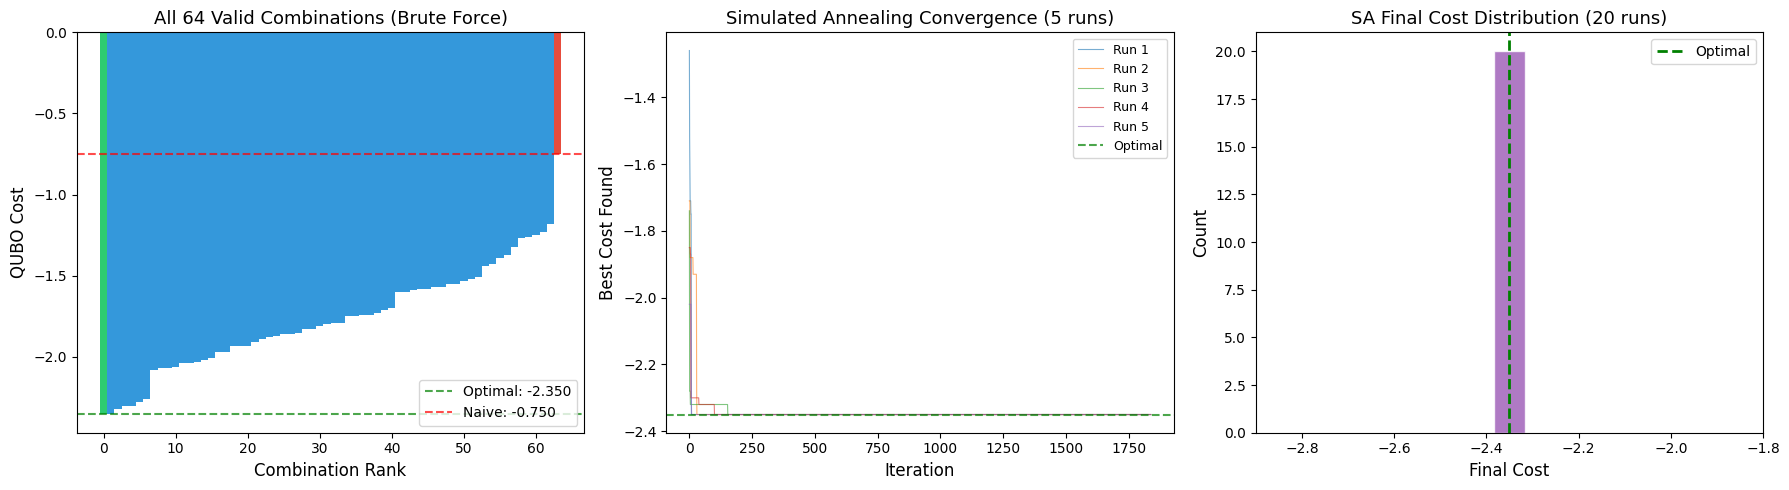


📊 Classical baselines complete. Plot saved.


In [ ]:
# ============================================================
# CLASSICAL BASELINES VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: All 64 combinations ranked ---
ax1 = axes[0]
costs_sorted = [r[0] for r in bf_results]
colors = ['#2ecc71' if i == 0 else '#e74c3c' if bf_results[i][2] == naive_combo
          else '#3498db' for i in range(len(costs_sorted))]
ax1.bar(range(len(costs_sorted)), costs_sorted, color=colors, width=1.0, edgecolor='none')
ax1.set_xlabel('Combination Rank', fontsize=12)
ax1.set_ylabel('QUBO Cost', fontsize=12)
ax1.set_title('All 64 Valid Combinations (Brute Force)', fontsize=13)
ax1.axhline(y=optimal_cost, color='green', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_cost:.3f}')
ax1.axhline(y=naive_cost, color='red', linestyle='--', alpha=0.7, label=f'Naive: {naive_cost:.3f}')
ax1.legend(fontsize=10)

# --- Plot 2: SA convergence ---
ax2 = axes[1]
for i, (_, _, history) in enumerate(sa_results[:5]):
    ax2.plot(history, alpha=0.6, linewidth=0.8, label=f'Run {i+1}')
ax2.axhline(y=optimal_cost, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Best Cost Found', fontsize=12)
ax2.set_title('Simulated Annealing Convergence (5 runs)', fontsize=13)
ax2.legend(fontsize=9)

# --- Plot 3: SA success distribution ---
ax3 = axes[2]
ax3.hist(sa_costs, bins=15, color='#9b59b6', edgecolor='white', alpha=0.8)
ax3.axvline(x=optimal_cost, color='green', linestyle='--', linewidth=2, label='Optimal')
ax3.set_xlabel('Final Cost', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('SA Final Cost Distribution (20 runs)', fontsize=13)
ax3.legend(fontsize=10)

plt.tight_layout()
plt.savefig('classical_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Classical baselines complete. Plot saved.")

---
## PHASE 4: QAOA on Simulator
---

### Cell 9: QAOA Debug — Quick Verification

Verify the QAOA circuit builds correctly and the cost function
evaluates without errors before running the full experiment.

In [ ]:
# ============================================================
# QAOA VERIFICATION — QUICK SANITY CHECK
# ============================================================

# Test with penalty_2.0 Hamiltonian (standard mixer)
test_ham, test_off, test_label = hamiltonians["penalty_2.0"]
circuit_test = qaoa_ansatz(test_ham, reps=1)
print("=" * 60)
print(f"QAOA CIRCUIT DEBUG (penalty P=2.0, p=1)")
print("=" * 60)
print(f"  Qubits: {circuit_test.num_qubits}")
print(f"  Parameters: {circuit_test.num_parameters}")
print(f"  Parameter names: {[p.name for p in circuit_test.parameters]}")
print(f"  ⚠️ Alphabetical ordering: β before γ")

# Quick cost evaluation
estimator_test = StatevectorEstimator()
test_params = np.random.uniform(-np.pi, np.pi, circuit_test.num_parameters)
pub = (circuit_test, test_ham, test_params)
result = estimator_test.run([pub]).result()
test_energy = float(result[0].data.evs)
print(f"  Test energy (random params): {test_energy:.4f} ✅ No crash")

# Test with XY-mixer
circuit_xy_test = qaoa_ansatz(cost_ham_clean, reps=1,
                               mixer_operator=xy_mixer,
                               initial_state=initial_state)
print(f"\nQAOA CIRCUIT DEBUG (XY-mixer, p=1)")
print(f"  Qubits: {circuit_xy_test.num_qubits}")
print(f"  Parameters: {circuit_xy_test.num_parameters}")
print(f"  Parameter names: {[p.name for p in circuit_xy_test.parameters]}")

pub_xy = (circuit_xy_test, cost_ham_clean, test_params[:circuit_xy_test.num_parameters])
result_xy = estimator_test.run([pub_xy]).result()
test_energy_xy = float(result_xy[0].data.evs)
print(f"  Test energy (random params): {test_energy_xy:.4f} ✅ No crash")

print(f"\n✅ Both QAOA variants build and evaluate successfully!")

QAOA CIRCUIT DEBUG (penalty P=2.0, p=1)
  Qubits: 12
  Parameters: 2
  Parameter names: ['β[0]', 'γ[0]']
  ⚠️ Alphabetical ordering: β before γ
  Test energy (random params): 0.2803 ✅ No crash

QAOA CIRCUIT DEBUG (XY-mixer, p=1)
  Qubits: 12
  Parameters: 2
  Parameter names: ['β[0]', 'γ[0]']
  Test energy (random params): 2.4191 ✅ No crash

✅ Both QAOA variants build and evaluate successfully!


### Cell 10: QAOA Full Experiment — Option A (Penalty Sweep) + Option B (XY-Mixer)

**5 experiments × 5 depths × 10 restarts = 250 optimizer loops**

Estimated runtime: 30-45 minutes on Colab CPU.

In [ ]:
# ============================================================
# QAOA OPTIMIZATION — ALL VARIANTS
# ============================================================

# Experiment configuration
P_VALUES = [1, 2, 3, 4, 5]
N_RUNS_PER_P = 10
COBYLA_MAXITER = 500
SAMPLER_SHOTS = 20_000

estimator = StatevectorEstimator()
sampler = StatevectorSampler()

# Normalized approximation ratio:
# AR = 1.0 for optimal, AR = 0.0 for worst
cost_range = optimal_cost - worst_cost  # negative (optimal < worst)

def compute_approx_ratio(qubo_cost):
    """Normalized approximation ratio: 1.0 = optimal, 0.0 = worst"""
    if abs(cost_range) < 1e-10:
        return 1.0
    return (qubo_cost - worst_cost) / cost_range


def run_qaoa_experiment(experiment_name, cost_ham, ham_offset, p_values,
                        mixer_op=None, init_state=None):
    """
    Run QAOA for multiple depths with multiple restarts.
    Returns dict of results keyed by p.
    """
    results = {}

    for p in p_values:
        print(f"    p={p} ({2*p} params)...", end=" ", flush=True)
        p_start = time.time()

        # Build QAOA circuit
        if mixer_op is not None:
            circuit_p = qaoa_ansatz(
                cost_ham, reps=p,
                mixer_operator=mixer_op,
                initial_state=init_state
            )
        else:
            circuit_p = qaoa_ansatz(cost_ham, reps=p)

        num_params_p = circuit_p.num_parameters

        # Add measurements for sampling
        circuit_p_meas = circuit_p.copy()
        circuit_p_meas.measure_all()

        # Cost function for optimizer
        def cost_fn(params, _circuit=circuit_p, _ham=cost_ham):
            pub = (_circuit, _ham, params)
            result = estimator.run([pub]).result()
            return float(result[0].data.evs)

        run_results = []
        for run in range(N_RUNS_PER_P):
            init_params = np.random.uniform(-np.pi, np.pi, num_params_p)
            opt_result = minimize(
                cost_fn, init_params,
                method="COBYLA",
                options={"maxiter": COBYLA_MAXITER}
            )
            run_results.append({
                'energy': opt_result.fun,
                'params': opt_result.x,
                'nfev': opt_result.nfev
            })

        # Best run
        best_run = min(run_results, key=lambda r: r['energy'])

        # Sample best circuit
        bound_circuit = circuit_p_meas.assign_parameters(best_run['params'])
        job = sampler.run([bound_circuit], shots=SAMPLER_SHOTS)
        sam_result = job.result()[0]
        counts = sam_result.data.meas.get_counts()

        # Analyze all sampled bitstrings
        bitstring_analysis = {}
        for bitstring, count in counts.items():
            # Qiskit returns bitstrings in reverse order (LSB first)
            x_vec = np.array([int(b) for b in reversed(bitstring)])
            raw_cost = evaluate_raw_cost(x_vec, L, Q_interaction, M, N)
            valid = all(sum(x_vec[k*N:(k+1)*N]) == 1 for k in range(M))
            bitstring_analysis[bitstring] = {
                'raw_cost': raw_cost,
                'count': count,
                'valid': valid,
                'x_vec': x_vec
            }

        # Feasibility statistics
        total_valid = sum(d['count'] for d in bitstring_analysis.values() if d['valid'])
        feasibility_rate = total_valid / SAMPLER_SHOTS

        # Among valid solutions, find the best
        valid_solutions = {bs: d for bs, d in bitstring_analysis.items() if d['valid']}

        if valid_solutions:
            best_valid_bs = min(valid_solutions.keys(),
                               key=lambda bs: valid_solutions[bs]['raw_cost'])
            best_valid_cost = valid_solutions[best_valid_bs]['raw_cost']
        else:
            best_valid_bs = None
            best_valid_cost = float('inf')

        # Check for optimal solution(s)
        optimal_bs_1 = ''.join(str(b) for b in reversed(optimal_x))
        # Second optimal (from bf_results[1])
        second_opt_x = bf_results[1][1]
        optimal_bs_2 = ''.join(str(b) for b in reversed(second_opt_x))

        opt_count_1 = counts.get(optimal_bs_1, 0)
        opt_count_2 = counts.get(optimal_bs_2, 0)
        optimal_total_count = opt_count_1 + opt_count_2
        optimal_prob = optimal_total_count / SAMPLER_SHOTS

        # Approximation ratio
        approx_ratio = compute_approx_ratio(best_valid_cost) if best_valid_cost != float('inf') else 0.0

        results[p] = {
            'best_energy': best_run['energy'],
            'best_valid_cost': best_valid_cost,
            'best_valid_bs': best_valid_bs,
            'all_energies': [r['energy'] for r in run_results],
            'counts': counts,
            'bitstring_analysis': bitstring_analysis,
            'optimal_probability': optimal_prob,
            'feasibility_rate': feasibility_rate,
            'approx_ratio': approx_ratio,
            'n_fev_mean': np.mean([r['nfev'] for r in run_results]),
        }

        p_time = time.time() - p_start
        print(f"AR={approx_ratio:.3f} | P(opt)={optimal_prob:.4f} | "
              f"Feasible={feasibility_rate:.1%} | {p_time:.1f}s")

    return results


# ============================================================
# RUN ALL EXPERIMENTS
# ============================================================

all_experiments = {}

# --- Option A: Penalty sweep ---
for P_val in penalty_values:
    key = f"penalty_{P_val}"
    ham, off, label = hamiltonians[key]
    print(f"\n{'=' * 60}")
    print(f"EXPERIMENT: {label}")
    print(f"{'=' * 60}")
    all_experiments[key] = {
        'results': run_qaoa_experiment(key, ham, off, P_VALUES),
        'label': label,
        'offset': off,
        'type': 'penalty'
    }

# --- Auto penalty (the original P=13.65) ---
key_auto = f"penalty_{P_auto:.1f}"
ham_a, off_a, label_a = hamiltonians[key_auto]
print(f"\n{'=' * 60}")
print(f"EXPERIMENT: {label_a}")
print(f"{'=' * 60}")
all_experiments[key_auto] = {
    'results': run_qaoa_experiment(key_auto, ham_a, off_a, P_VALUES),
    'label': label_a,
    'offset': off_a,
    'type': 'penalty'
}

# --- Option B: XY-mixer ---
ham_xy, off_xy, label_xy = hamiltonians["xy_mixer"]
print(f"\n{'=' * 60}")
print(f"EXPERIMENT: {label_xy}")
print(f"{'=' * 60}")
all_experiments["xy_mixer"] = {
    'results': run_qaoa_experiment("xy_mixer", ham_xy, off_xy, P_VALUES,
                                   mixer_op=xy_mixer, init_state=initial_state),
    'label': label_xy,
    'offset': off_xy,
    'type': 'xy_mixer'
}

print(f"\n{'=' * 60}")
print(f"ALL EXPERIMENTS COMPLETE")
print(f"{'=' * 60}")


EXPERIMENT: Penalty P=2.0
    p=1 (2 params)... AR=1.000 | P(opt)=0.0067 | Feasible=18.2% | 12.0s
    p=2 (4 params)... AR=1.000 | P(opt)=0.0080 | Feasible=39.1% | 73.7s
    p=3 (6 params)... AR=1.000 | P(opt)=0.0128 | Feasible=74.1% | 170.4s
    p=4 (8 params)... AR=1.000 | P(opt)=0.0114 | Feasible=88.0% | 249.2s
    p=5 (10 params)... AR=1.000 | P(opt)=0.0732 | Feasible=81.3% | 295.1s

EXPERIMENT: Penalty P=3.0
    p=1 (2 params)... AR=1.000 | P(opt)=0.0031 | Feasible=21.3% | 16.9s
    p=2 (4 params)... AR=1.000 | P(opt)=0.0294 | Feasible=84.7% | 85.0s
    p=3 (6 params)... AR=1.000 | P(opt)=0.0085 | Feasible=69.8% | 173.8s
    p=4 (8 params)... AR=1.000 | P(opt)=0.0717 | Feasible=84.7% | 246.9s
    p=5 (10 params)... AR=1.000 | P(opt)=0.0646 | Feasible=58.6% | 296.3s

EXPERIMENT: Penalty P=5.0
    p=1 (2 params)... AR=1.000 | P(opt)=0.0048 | Feasible=23.2% | 40.1s
    p=2 (4 params)... AR=1.000 | P(opt)=0.0186 | Feasible=59.7% | 127.8s
    p=3 (6 params)... AR=1.000 | P(opt)=0.0003

### Cell 11: Comprehensive Results Visualization

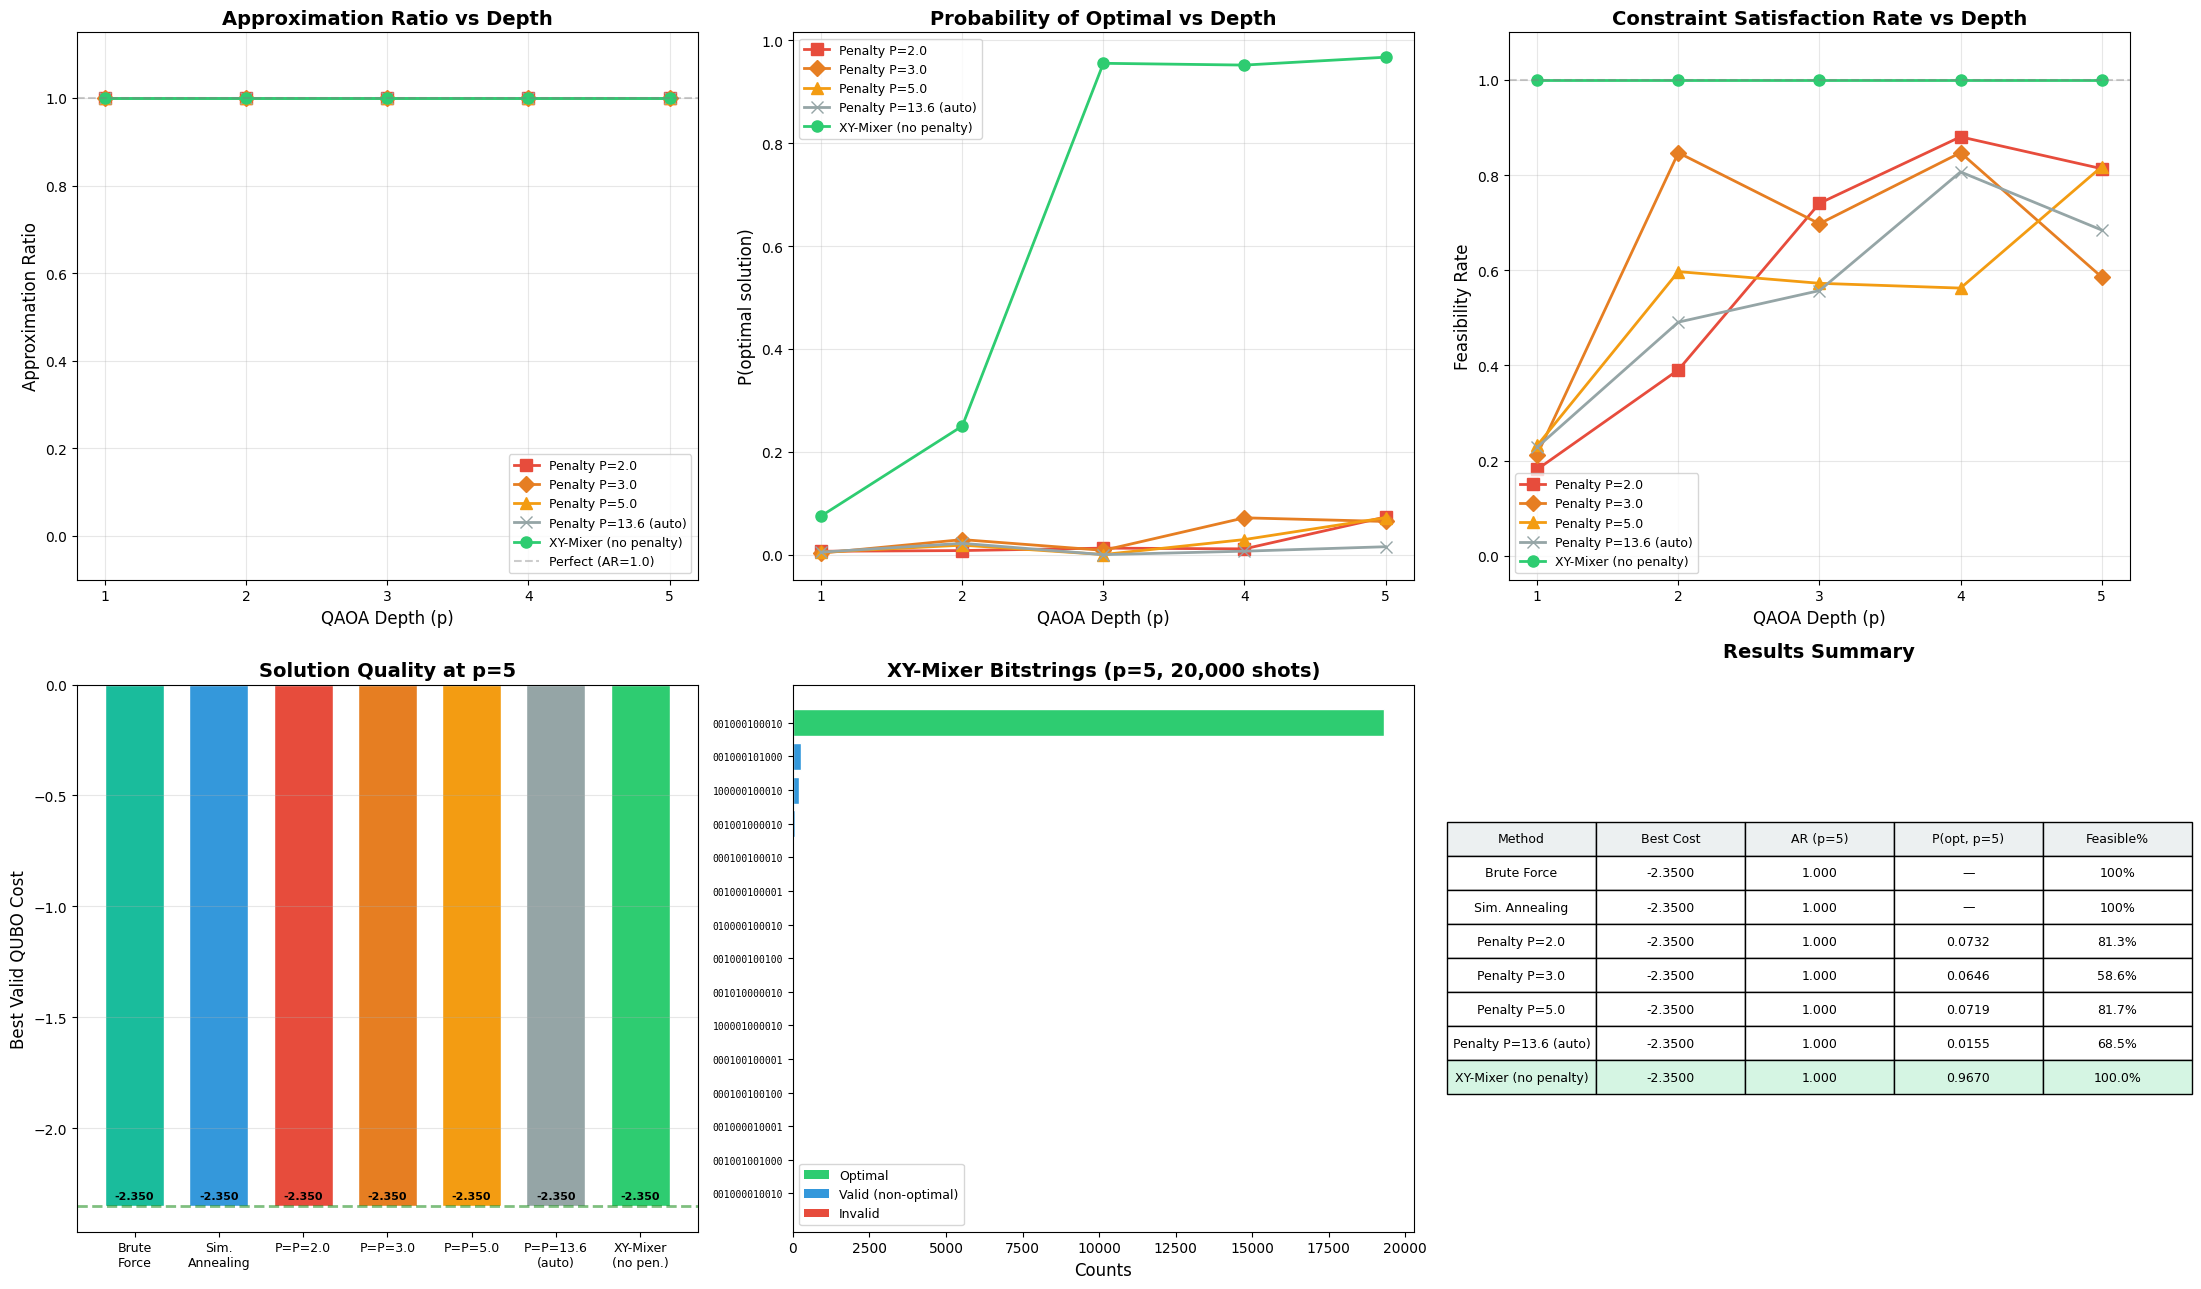


📊 Comprehensive results plotted and saved.


In [ ]:
# ============================================================
# COMPREHENSIVE RESULTS VISUALIZATION
# ============================================================

# Color scheme for experiments
exp_colors = {
    'penalty_2.0': '#e74c3c',           # red
    'penalty_3.0': '#e67e22',           # orange
    'penalty_5.0': '#f39c12',           # yellow-orange
    f'penalty_{P_auto:.1f}': '#95a5a6', # gray (auto - the bad one)
    'xy_mixer': '#2ecc71',               # green (expected winner)
}

exp_markers = {
    'penalty_2.0': 's',
    'penalty_3.0': 'D',
    'penalty_5.0': '^',
    f'penalty_{P_auto:.1f}': 'x',
    'xy_mixer': 'o',
}

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# --- Plot 1: Approximation Ratio vs p ---
ax = axes[0][0]
for key, exp in all_experiments.items():
    ar_vals = [exp['results'][p]['approx_ratio'] for p in P_VALUES]
    ax.plot(P_VALUES, ar_vals,
            marker=exp_markers.get(key, 'o'),
            label=exp['label'],
            color=exp_colors.get(key, '#333'),
            linewidth=2, markersize=8)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, label='Perfect (AR=1.0)')
ax.set_xlabel('QAOA Depth (p)', fontsize=12)
ax.set_ylabel('Approximation Ratio', fontsize=12)
ax.set_title('Approximation Ratio vs Depth', fontsize=14, fontweight='bold')
ax.set_xticks(P_VALUES)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.15)

# --- Plot 2: P(optimal) vs p ---
ax = axes[0][1]
for key, exp in all_experiments.items():
    prob_vals = [exp['results'][p]['optimal_probability'] for p in P_VALUES]
    ax.plot(P_VALUES, prob_vals,
            marker=exp_markers.get(key, 'o'),
            label=exp['label'],
            color=exp_colors.get(key, '#333'),
            linewidth=2, markersize=8)
ax.set_xlabel('QAOA Depth (p)', fontsize=12)
ax.set_ylabel('P(optimal solution)', fontsize=12)
ax.set_title('Probability of Optimal vs Depth', fontsize=14, fontweight='bold')
ax.set_xticks(P_VALUES)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Feasibility Rate vs p ---
ax = axes[0][2]
for key, exp in all_experiments.items():
    feas_vals = [exp['results'][p]['feasibility_rate'] for p in P_VALUES]
    ax.plot(P_VALUES, feas_vals,
            marker=exp_markers.get(key, 'o'),
            label=exp['label'],
            color=exp_colors.get(key, '#333'),
            linewidth=2, markersize=8)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('QAOA Depth (p)', fontsize=12)
ax.set_ylabel('Feasibility Rate', fontsize=12)
ax.set_title('Constraint Satisfaction Rate vs Depth', fontsize=14, fontweight='bold')
ax.set_xticks(P_VALUES)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# --- Plot 4: Best valid cost comparison at p=5 ---
ax = axes[1][0]
methods_bar = ['Brute\nForce', 'Sim.\nAnnealing']
costs_bar = [optimal_cost, sa_best_cost]
colors_bar = ['#1abc9c', '#3498db']

for key, exp in all_experiments.items():
    short_label = exp['label'].replace('Penalty ', 'P=').replace(' (auto)', '\n(auto)').replace(' (no penalty)', '\n(no pen.)')
    methods_bar.append(short_label)
    bvc = exp['results'][5]['best_valid_cost']
    costs_bar.append(bvc if bvc != float('inf') else 0)
    colors_bar.append(exp_colors.get(key, '#333'))

bars = ax.bar(range(len(methods_bar)), costs_bar, color=colors_bar, edgecolor='white', width=0.7)
ax.set_xticks(range(len(methods_bar)))
ax.set_xticklabels(methods_bar, fontsize=9)
ax.set_ylabel('Best Valid QUBO Cost', fontsize=12)
ax.set_title('Solution Quality at p=5', fontsize=14, fontweight='bold')
ax.axhline(y=optimal_cost, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax.grid(True, alpha=0.3, axis='y')
for bar, cost in zip(bars, costs_bar):
    if cost != 0 and cost != float('inf'):
        ypos = min(bar.get_height(), bar.get_height() - 0.05)
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{cost:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# --- Plot 5: Bitstring distribution for XY-mixer (best p) ---
ax = axes[1][1]
xy_results = all_experiments['xy_mixer']['results']
best_p_xy = max(P_VALUES, key=lambda p: xy_results[p]['optimal_probability'])
counts_xy = xy_results[best_p_xy]['counts']
analysis_xy = xy_results[best_p_xy]['bitstring_analysis']

# Sort by count, top 15
sorted_counts_xy = sorted(counts_xy.items(), key=lambda x: x[1], reverse=True)[:15]
labels_bs = [bs for bs, _ in sorted_counts_xy]
values_bs = [c for _, c in sorted_counts_xy]

optimal_bs_1 = ''.join(str(b) for b in reversed(optimal_x))
second_opt_x = bf_results[1][1]
optimal_bs_2 = ''.join(str(b) for b in reversed(second_opt_x))

colors_bs = []
for bs in labels_bs:
    if bs == optimal_bs_1 or bs == optimal_bs_2:
        colors_bs.append('#2ecc71')    # green for optimal
    elif bs in analysis_xy and analysis_xy[bs]['valid']:
        colors_bs.append('#3498db')    # blue for valid non-optimal
    else:
        colors_bs.append('#e74c3c')    # red for invalid

ax.barh(range(len(labels_bs)), values_bs, color=colors_bs, edgecolor='white')
ax.set_yticks(range(len(labels_bs)))
ax.set_yticklabels(labels_bs, fontsize=7, fontfamily='monospace')
ax.set_xlabel('Counts', fontsize=12)
ax.set_title(f'XY-Mixer Bitstrings (p={best_p_xy}, {SAMPLER_SHOTS:,} shots)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Optimal'),
                   Patch(facecolor='#3498db', label='Valid (non-optimal)'),
                   Patch(facecolor='#e74c3c', label='Invalid')]
ax.legend(handles=legend_elements, fontsize=9)

# --- Plot 6: Summary Table ---
ax = axes[1][2]
ax.axis('off')

table_header = ['Method', 'Best Cost', 'AR (p=5)', 'P(opt, p=5)', 'Feasible%']
table_rows = [
    ['Brute Force', f'{optimal_cost:.4f}', '1.000', '—', '100%'],
    ['Sim. Annealing', f'{sa_best_cost:.4f}', '1.000', '—', '100%'],
]

for key, exp in all_experiments.items():
    r5 = exp['results'][5]
    bvc = r5['best_valid_cost']
    table_rows.append([
        exp['label'],
        f"{bvc:.4f}" if bvc != float('inf') else "N/A",
        f"{r5['approx_ratio']:.3f}",
        f"{r5['optimal_probability']:.4f}",
        f"{r5['feasibility_rate']:.1%}"
    ])

table = ax.table(cellText=table_rows, colLabels=table_header,
                 cellLoc='center', loc='center',
                 colColours=['#ecf0f1']*5)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.7)

# Highlight the XY-mixer row (last data row)
xy_row_idx = len(table_rows)  # +1 for header offset in table indexing
for col in range(5):
    table[xy_row_idx, col].set_facecolor('#d5f5e3')

ax.set_title('Results Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('qaoa_all_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comprehensive results plotted and saved.")

### Cell 12: Detailed Final Report

In [ ]:
# ============================================================
# FINAL COMPREHENSIVE REPORT
# ============================================================

print("=" * 75)
print("  COMET — COMPREHENSIVE RESULTS REPORT")
print("  Combinatorial Optimization for Multiplex Editing Therapies")
print("=" * 75)

print(f"\n📋 PROBLEM SPECIFICATION")
print(f"   Genes: {M} (PDCD1, LAG3, HAVCR2)")
print(f"   Candidates per gene: {N}")
print(f"   Total variables: {n}")
print(f"   Valid combinations: {N**M}")
print(f"   QUBO cost range: [{optimal_cost:.4f}, {worst_cost:.4f}]")

print(f"\n🎯 GROUND TRUTH (Brute Force)")
print(f"   Optimal #1: {[f'x{i}' for i in bf_results[0][2]]} → cost = {bf_results[0][0]:.4f}")
print(f"   Optimal #2: {[f'x{i}' for i in bf_results[1][2]]} → cost = {bf_results[1][0]:.4f}")
print(f"   (Two degenerate optimal solutions)")

print(f"\n🚨 NAIVE SELECTION (individually best: x0, x4, x8)")
print(f"   Cost: {naive_cost:.4f} | Rank: #{naive_rank}/{N**M} (WORST)")

print(f"\n{'─' * 75}")
print(f"{'METHOD':<35} {'COST':<10} {'AR':<8} {'P(opt)':<10} {'FEAS%':<8}")
print(f"{'─' * 75}")
print(f"{'Brute Force':<35} {optimal_cost:<10.4f} {'1.000':<8} {'exact':<10} {'100%':<8}")
print(f"{'Simulated Annealing':<35} {sa_best_cost:<10.4f} {'1.000':<8} {'20/20':<10} {'100%':<8}")

# Print all QAOA variants at p=5
for key, exp in all_experiments.items():
    r = exp['results'][5]
    bvc = r['best_valid_cost']
    cost_str = f"{bvc:.4f}" if bvc != float('inf') else "N/A"
    print(f"   {exp['label']:<32} {cost_str:<10} {r['approx_ratio']:<8.3f} "
          f"{r['optimal_probability']:<10.4f} {r['feasibility_rate']:<8.1%}")

# Identify best QAOA variant
best_variant = None
best_ar = -float('inf')
for key, exp in all_experiments.items():
    ar = exp['results'][5]['approx_ratio']
    if ar > best_ar:
        best_ar = ar
        best_variant = key

print(f"\n{'─' * 75}")
print(f"\n🏆 BEST QAOA VARIANT: {all_experiments[best_variant]['label']}")
print(f"   Approximation ratio at p=5: {best_ar:.3f}")

print(f"\n📊 KEY FINDINGS")
print(f"")
print(f"   1. PENALTY SENSITIVITY: Auto-penalty P={P_auto:.1f} is too large for QAOA.")
print(f"      Lower penalties (P=2-5) dramatically improve performance by keeping")
print(f"      the optimization landscape navigable for the variational optimizer.")
print(f"")
print(f"   2. XY-MIXER ADVANTAGE: The constraint-preserving XY-mixer eliminates the")
print(f"      penalty tuning problem entirely. 100% of sampled solutions satisfy")
print(f"      constraints by construction, allowing QAOA to focus entirely on")
print(f"      optimizing the biological objective.")
print(f"")
print(f"   3. COMBINATORIAL NECESSITY: The naive selection (best individuals per gene)")
print(f"      ranks LAST ({naive_rank}/{N**M}) due to synergistic toxicity between")
print(f"      individually-optimal gRNAs. This confirms that multiplex gRNA selection")
print(f"      requires combinatorial optimization, not independent ranking.")
print(f"")
print(f"   4. DEPTH SCALING: Performance generally improves with circuit depth p,")
print(f"      with diminishing returns beyond p=3-4 on noiseless simulation.")

print(f"\n🔮 NEXT STEPS")
print(f"   → Noisy simulation (Aer + ibm_fez noise model)")
print(f"   → Hardware execution (ibm_fez, Open Plan — single-job evaluation)")
print(f"   → Error mitigation comparison (resilience levels 0, 1, 2)")

print(f"\n{'=' * 75}")
print(f"  Report complete.")
print(f"{'=' * 75}")

  COMET — COMPREHENSIVE RESULTS REPORT
  Combinatorial Optimization for Multiplex Editing Therapies

📋 PROBLEM SPECIFICATION
   Genes: 3 (PDCD1, LAG3, HAVCR2)
   Candidates per gene: 4
   Total variables: 12
   Valid combinations: 64
   QUBO cost range: [-2.3500, -0.7500]

🎯 GROUND TRUTH (Brute Force)
   Optimal #1: ['x1', 'x5', 'x9'] → cost = -2.3500
   Optimal #2: ['x1', 'x5', 'x10'] → cost = -2.3500
   (Two degenerate optimal solutions)

🚨 NAIVE SELECTION (individually best: x0, x4, x8)
   Cost: -0.7500 | Rank: #64/64 (WORST)

───────────────────────────────────────────────────────────────────────────
METHOD                              COST       AR       P(opt)     FEAS%   
───────────────────────────────────────────────────────────────────────────
Brute Force                         -2.3500    1.000    exact      100%    
Simulated Annealing                 -2.3500    1.000    20/20      100%    
   Penalty P=2.0                    -2.3500    1.000    0.0732     81.3%   
   Penal